### Here comes an outline of what this code goes through:

The scope of the code is to solve for the optimal job search effort for people who have recently lost their job and are now on unemployment benefits. 

To do that we need to know what the value of being employed and unemployed is. The value of being unemployed and employed depends on the amount of assets that one holds and the reference income that the person has in the current period. Ones the value of being employed and unemployed in every period and for every asset level is found we can compute the maximal search effort in each period and for all asset levels. 

The optimal search effort is then used to compute the 'hazard rates' (meaning the rate of exit from unemployment benefits). Finally, we have to check how vulnerable our estimated hazard rates are to different assumptions and different benefit levels. 

#### 1. We find the steady state value of being either employed or unemployed by using value function iterations. 
#### 2. We create the income path and the reference income path
The agent uses the average of the last N periods to calculate its reference. 
#### 3. We use the reference path and the steady state value of employment to find the full value of employment in every period and for every asset level. 
We do that through backwards induction for the N periods of reference until the reference level is completely adjusted to having a wage income. In the N periods we evaluate at the gain level of the utility function.n
#### 4. We write up the search cost function

#### 5. We use the search cost function to backwards iterate to the optimal consumption level and search effort for all asset levels and for every period. 

------------------------------------------------------------------------------------------------

Now I haven't gotten any further, but what we have to do is: 
1. find the inverse of the optimal search cost function
2. Use that in combination with the relative values of employment and unemployment to find the hazard rates. 

------------------------------------------------------------------------------------------------

In [1]:
import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate  # Interpolation routines
#from scipy.optimize import fsolve
#import model.py as model

#### 1. We find the SS values of employment and unemployment

It is a cake eating problem in the infinite horizon where the remaining cake grows with a given rate and an absolute factor too. 
$A' = (1+R)(A+w-c)$

And the the bellman equation is: 
$V(A) = max_{c \in A+w} ln (c) + \delta   V [(1+R)(A+w-c)]  $ \\

We can substitute $c = w + A + A' / (1+R) $ to get: \\

$V(A) = max_{0 \le A' \le A+w} ln (w + A + A' / (1+R)) + \delta   V ( A' )  $

Which is a problem solely with A, that is given and A´ which is the optimizing factor. 

In [29]:
delta = 0.93
gamma = 0.9
eta = 1
k = 300
lmbda = 4.9

abar = [0, 10000]
n_a = 100
n_c = 150

T1 = 6
T2 = 18
T3 = 24
T = 44
N = 6
b1= 222
b2 = 222
b3 = 114 
welfare = 90
w = 675
R = 0.01


In [30]:
class ss_value:
    """Class to implement the stochastic cake eating model with discretized choice"""

    def __init__(self, delta, abar, n_a, n_c, w, R ):
        """Initializer"""
        self.delta = delta    # Discount factor
        self.abar = abar    # min and max savings
        self.n_a = n_a      # grid size for state variable
        self.n_c = n_c      # grid size for choice grid
        self.w = w          # wage
        self.R = R          # interest rate

        self.abar[0] = np.maximum(np.finfo(float).eps, self.abar[0])       # vælger den højeste værdi af minimumsværdien for abar og 'numerisk 0'. Vi vil ikke under numerisk 0.  
        # truncate lower bound at smallest positive float number
        # parameter dependent varibles
        self.a = np.linspace(self.abar[0], self.abar[1], n_a).reshape((n_a, 1))  # vi laver en vektor med state space fra 0 til abar og med det antal grid punkter vi vil have, n_a.  
        self.c = np.empty((n_a, n_c))  # starter consumption matrix med rækker for alle states og så et finere grid i kolonnerne for mulige consumption valg. 
        
        for i in range(n_a):            # fordi rækkerne er state-grids, så derfor skal vi have en række for hver state vi vil kigge på
            self.c[i, :] = np.linspace(self.abar[0], self.a[i]+self.w, n_c).reshape((1, n_c))  # vi laver hver række så den går fra '0' til den værdi i state grid, som vi kigger på. Altså, det vil svare til at vi kigger på alle mulige værdier for V(A=10)
                                                                                        # consumption choice bliver så lidt finere (det er kolonnerne her) og tager n_c grid points. 
                                                                                        # så hver række repræsenterer alle consumption choices givet en state value. 
        """" Det her er nok forkert. Vi skal have tilføjet + w i forbrugsmuligheden"""

        """Bellman operator, V0 is one-dim vector of values on state grid"""
    def bellman(self, V0, R):
        interp = interpolate.interp1d(self.a[:, 0], V0, bounds_error=False, fill_value="extrapolate")
        V = 0
        a1 = (self.a - self.c + self.w)*(1+self.R)       # vi laver a1 som funktion af hvad du forbruger     'a' er en 1 x n_a vektor

        print("Asset grid:")
        print(self.a.min(), self.a.max())

        print("A_next:")
        print(a1.min(), a1.max())

        print(
            "Share above grid:",
            np.mean(a1 > self.a.max())
        )

        print(
            "Share below grid:",
            np.mean(a1 < self.a.min())
        )
        
        V = interp(a1)                              # a1 bliver en n_a x n_c matrix     V svarer til de 100 forskellige niveauer af nytte i næste periode
                                                    # a1 er en funktion af c (de andre er faste), så får vi en værdi som ligger mellem grid points ved at interpolere.
                                                    # der er ikke noget med nytte. Er det med vilje fordi den endelige værdi af V altid være den som maksimerer nytten?
        matV1 = np.log(self.c) + self.delta * V      # c er en n_a x n_c vektor   a er en na x 1 vektor a1 bliver så en n_a x n_c matrix. Det gør V så også 
                                                    # så her lægges en n_a x n_c matrix til en n_a x n_c matrix, hvilket giver en n_a x n_c matrix.
        i_max = np.argmax(matV1, axis=1)            # vi kigger på den kolonne som giver den højeste nytte for hver række. n_a x 1 matrix
        # (column) index of optimal choices
        V1 = matV1[np.arange(self.n_a), i_max]          # Her går den igennem alle n_a rækker, og finder den kolonne i hver række, som giver den højeste værdi. 
        c1 = self.c[np.arange(self.n_a), i_max]         # den her viser, hvad det optimale forbrug så viste sig at være. 

        return V1, c1
    

Adding the value function iteration solver of the Bellman equation to the class. 

In [31]:
def vfi(self, maxiter=100000, tol=1e-9, callback=None):
    """Solves the model using VFI (successive approximations)"""
    tic = process_time()  # Start the stopwatch / counter

    V0 = np.log(self.a[:, 0])  # on first iteration assume consuming everything
    """eventuelt tilføj w i den initialle V0"""
    for iter in range(maxiter):
        V1, c1 = self.bellman(V0, self.R)
        if callback:
            callback(iter, self.a, V1, c1)  # callback for making plots
        if np.all(abs(V1 - V0) < tol):
            toc = process_time()  # Stop the stopwatch / counter
            print("Optimal consumption of assets solved in", iter, "iterations, using", round(toc - tic, 5), "seconds")
            break
        V0 = V1
    else:  # when i went up to maxiter
        print("No convergence: maximum number of iterations achieved!")
    return V1, c1

# Add the vfi_solve method to the cake_stochastic class
ss_value.solve = vfi

Here we export the SS values and associated consumption for both employment and unemployment for every asset level. 
It is the same code. The only difference is the wage in the final period, which is either a wage for a job or the welfare level of income. 

emp = ss_value(delta, abar, n_a, n_c, w, R)
Vss_emp, css_emp = emp.solve()

uemp = ss_value(delta, abar, n_a, n_c, w, R)
Vss_uemp, css_uemp = uemp.solve() 

Here the value function and the consumption for both being employed and unemployed for every asset level in steady state is plotted against each other 
- we can experiment with the plots a little bit. 

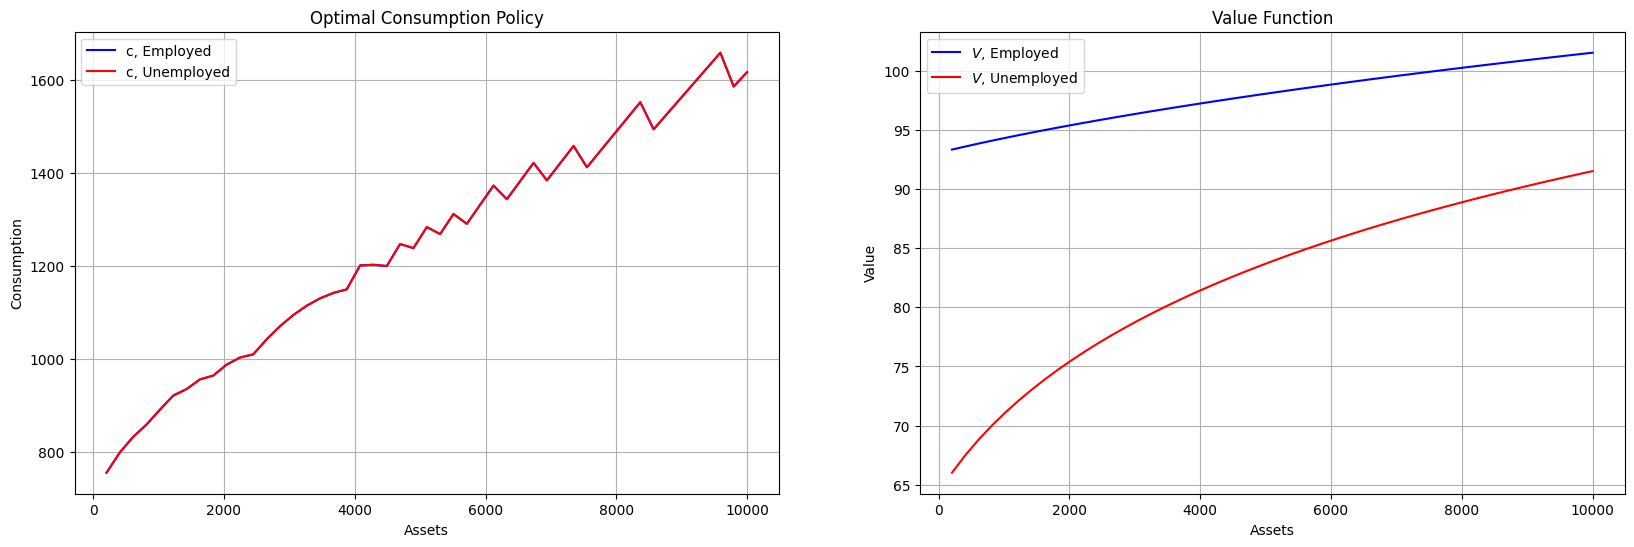

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
ax1.grid(True)
ax2.grid(True)
ax1.plot(emp.a[1:], css_emp[1:], color="b", label="c, Employed")
ax1.plot(emp.a[1:], css_uemp[1:], color="r", label="c, Unemployed")
ax1.set_xlabel("Assets")
ax1.set_ylabel("Consumption")
ax1.legend()
ax1.set_title("Optimal Consumption Policy")
ax2.plot(emp.a[1:], Vss_emp[1:], color="b", label="$V$, Employed")
ax2.plot(emp.a[1:], Vss_uemp[1:], color="r", label="$V$, Unemployed")
ax2.legend()
ax2.set_title("Value Function")
ax2.set_xlabel("Assets")
ax2.set_ylabel("Value")
plt.show()

Consumption burde jo ikke variere på den måde, men i stedet være roligt voksende funktioner. 

------------------------------------------------------------------------------------------------------------------------------------------------


#### 2. We find the income path and through that the reference path for getting a job in every period



In [33]:
class ref_inc_path():
    def __init__(self,w , b1, b2, b3, welfare, T1, T2, T3, T, N, eta ):
        self.w = w              # Løn
        self.b1 = b1            # højeste dagpengesats    
        self.b2 = b2            # næste dagepengesats
        self.b3 = b3            # laveste dagpengesats
        self.welfare = welfare  # 'kontanthjælp'
        self.T1 = T1            # periode til højeste dagpengesats
        self.T2 = T2            # periode til næste dagpengesats
        self.T3 = T3            # periode til laveste dagpengesats
        self.T = T              # periode til kontanthjælp
        self.N = N              # antal referenceperioder
        self.eta = eta          # det er for at kunne modificere løsningen til også at være ikke reference-dependent
        self.n_periods = self.T + 1 # Perioder i alt (job kan starte i periode 0 til T, og så er der en ekstra periode hvor man aldrig finder et job)
        self.never_emp = self.T + 1 # Periode hvor man aldrig finder et job. Vi laver en ekstra række i income path, som repræsenterer dette.
        

    def benefit_path_(self):                # vi laver income paths som en T, array med alle income levels for forskellige perioder
        '''
        Returns the benefit path given parameter values.
            Arguments:
                b1,b2,b3,welfare (all floats): values at distinct time windows during unemployment
                T1,T2,T3 (int): points in Unemp. spell when benefit levels change.
                T (int): Total number of periods
            Returns:
                benefits (array): Benefit path in unemployment
        '''
        benefits        = np.zeros(self.T)       # Laver en vektor med T, elementer. 
        benefits[0:self.T1]  = self.b1                # for de rigtige tidspunkter tilføjer den benefit levels. 
        benefits[self.T1:self.T2] = self.b2
        benefits[self.T2:self.T3] = self.b3
        benefits[self.T3:self.T]  = self.welfare

        return benefits

 
    def income_path_(self):                          
        '''Laver alle de mulige income paths. 
            En for alle tidspunkter hvorpå man finder et job, inklusiv muligheden for aldrig at finde et job
        '''
        benefits = self.benefit_path_()
        income_path = np.tile(benefits,(self.T+2,1))
        for j in np.arange(self.n_periods): 
            income_path[j,j:] = self.w

        income_path[self.never_emp, :] = self.welfare
        return income_path
    
    def ref_path_(self):             # the reference point is given as the arithmetic average of the income in the 5 periods leading up to the current one. 
        if self.eta > 0: 
            ref_path = np.zeros((self.T+2, self.T))
            income_path = self.income_path_()
        
            for t in np.arange(self.T): 
                if t == 0:
                    ref_path[:,t] = self.w         # vi antager at lønnen før og lønnen efter bistand er den samme. 

                if t > 0: 
                    N_pre = max(self.N - t, 0)  # vi sætter antal perioder med løn til at blive mindre, når man har været længere tid på DP. Indtil løn slet ikke indgår i referencen. 
                    '''Her modificerer jeg koden ned i kompleksitet, så vi ikke tager højde for eventuelle halve perioder. 
                    Da vi slet ikke har dem med. Se rdmodel.py, for den komplekse udgave'''
                    start = max(t-self.N, 0)
                    end = t
                        #Her laver vi summen / gennemsnittet. 
                        #Når t > 4 så betyder N_pre leddet ikke længere noget.
                    ref_path[:,t] = ( N_pre*self.w + np.sum(income_path[:,start:end], axis = 1, keepdims=False ) ) / self.N
            
                    # reference path tager gennemsnittet for de seneste fem perioder af indkomst for alle rækker i income path.
                    # så altid summen af de t-5 til t søjler i income path plus evt. led fra før dagpenge, hvis vi er i t < 5
                    # axis = 1 betyder at vi kigger på søjler keepdims = False betyder at vi kun returner en vektor med t værdier pr. række.
                    # så hver række i income path repræsenterer, hvornår man får job. Hver række i r repræsenterer den dertilhørende lønreference i alle perioder. 
        else: 
            ref_path = self.income_path_()    
            
        return ref_path
         
        
    def ref_path_long_(self):        # we create this to get the future values of ref-dependence when getting a job inside T-N last periods.
            
        add = np.zeros( (self.T+2, self.N)  )

        ref_path = self.ref_path_()
        ref_path_long = np.concatenate((ref_path, add), axis = 1)      # now we add N columns to the ref_path_
            
        income_path = self.income_path_()       # we add the income path to use it later

        for t in np.arange(self.T, self.T + self.N):
                
            start = min ( t - self.N , self.T)      # vi definerer start som den periode vi er i og minus de N perioder vi kigger tilbage. Vi går indtil sidste periode i income_path
            end = self.T                            # det her er måske overflødigt, fordi vi bare siger, at vi stopper ved enden. 

            ref_path_long[:,t] = (  np.sum(income_path[:,start:], axis = 1, keepdims=False     )   + (t-self.T)* self.w ) / self.N 
                                        # so what the code does is that it takes the sum of the last periods available in the income path
                                        # plus the sum of the periods not available and divides by N to get the average.                                  
        """ændrer den sidste række til blot at være den samme som den var før men 5 perioder mere, fordi han aldrig får et job. """
        # Række til dem der aldrig får et job
        ref_path_long[self.never_emp, self.T:] = self.welfare
        
        return ref_path_long
               

model = ref_inc_path(w, b1, b2, b3, welfare, T1, T2, T3, T, N, eta )
ref_path_long = model.ref_path_long_()
benefits = model.benefit_path_()
print(benefits)

#print(ref_path_long[54,50:])        # this is getting the job in period T + 1 that's why it doesn't converge. 
#print(ref_path_long.shape)


------------------------------------------------------------------------------------------------------------------------------------------------

#### 3. We find the full value of getting a job for every asset level in every period

We solve the following maximization problem for every asset level in every period

$   V(A_t) = max _{0 \le A_{t+1} \le A_t } u \left(w+A_t + \frac{A_{t+1}}{1+R} \right) + \eta \left( u[w+A_t + \frac{A_{t+1}}{1+R}] - u[r_t]  \right)  + V(A_{t+1})    $ 




We call the steady state value function that we have already made in step 1

In [34]:
def employment_BI(Vss, ref_path, delta, eta, R, w, abar, T, N, n_a, n_c):
    abar[0] = np.maximum(np.finfo(float).eps, abar[0])              # vælger numerisk nul, så vi kan tage log. 
    a = np.linspace(abar[0], abar[1], n_a).reshape((n_a, 1))        # laver en n_a x 1 matrice med værdierne fra 0 til maks asset level. 

    c = np.empty((n_a, n_c))    # For hver state kan man vælge n_c forskellige niveauer af forbrug i perioden
    for i in range(n_a):        # vi kigger på alle rækkerne og tilføjer forbrugsmuligheder fra 0 og op til maks forbrug som er givet ved assets + løn.  
        c[i, :] = np.linspace(abar[0], (a[i]+w), n_c).reshape((1, n_c))     # Laver det om til en vektor med 1 række og n_c kolonner. 

    a1 = (a - c + w) * (1 + R)   # assets i næste periode. Det er en n_a x n_c matrix. 

    V_emp = np.zeros((T+1, n_a))   # placeholder variable for getting the job in period in period T with asset value a. 
    c_emp = np.zeros((T+1, n_a))   # associated optimal consumption, first period after job start, not really that relevant though...

    for j in np.arange(T+1):
        V0 = Vss   # steady state value from the value function iterations. 

        # step backward: n = N-1 (period closest to steady state) down to n = 0 (period job starts)
        for n in np.arange(N-1, -1, -1):
            interp = interpolate.interp1d(a[:, 0], V0, bounds_error=False, fill_value="extrapolate")    # here it always takes the latest V0 value, so a new one in every period. This is where the updated values get used. 
            V_next = interp(a1)     # V_next er jo altid den seneste værdi. Første del af loopet er så den 'interpolerede' værdi fra v_ss af givne asset levels mellem grids. 

            matV1 = np.log(c) + eta * (np.log(c) - np.log(ref_path[j, j+n])) + delta * V_next    # nytteværdi for givet 'j' jobtidspunkt for n-perioder efter job er fundet. 
                                                            # og så fordi at c er defineret som alle forbrugsmuligheder med forskellige asset levels overholdet det budget begrænsningen. 
            i_max = np.argmax(matV1, axis=1)                # hvordan overholder vi budgetbegrænsningen i næste periode? 
            V0 = matV1[np.arange(n_a), i_max]               # her opdateres værdierne givet det optimale forbrugsval. Det bliver så genbrugt til næste periode. 
            c_current = c[np.arange(n_a), i_max]

        V_emp[j, :] = V_emp[j,:] + V0
        c_emp[j, :] = c_current

    V_emp = V_emp.transpose()
    c_emp = c_emp.transpose()
    return V_emp, c_emp

Her får vi værdierne. c_out er lidt ligemeget, fordi det er den endelige c-værdi, hvilket vi egentlig ikke skal bruge. Altså, vi tracker slet ikke på den her måde den rigtige consumption path, men kun den sidste værdi. Vi skal heller ikke rigtigt bruge den, men hvis vi vil, så har claude lavet et udkast til kode for det, som ligger i VFI asset. 

We output the values of employment for every period and every asset level.

V_emp, c_emp = employment_BI(Vss_emp , ref_path_long, delta, eta, R, w, abar, T, N, n_a, n_c)

print(V_emp[:,54])       # kolonnerne er asset levels
                        # rækkerne er tidspunkter at få jobbet på
                        
                        # det kan vi se her fordi at der sket et rigtig stort spring fra asset level 0 til 1. Ikke længere faktisk, fordi der nu kommer en løn. 
                        # Hvilket kommer af nytten fra logaritmen til approksimativt 0 er næsten minus uendelig. 

print(V_emp[49,:])       # vi kan også se det ved det her print, hvor nogle af værdierne er ens fordi personerne når at tilpasse sig de nye lavere niveauer af indkomst. 
                        
# vi kan også bare se det ved at kigge på shape, hvor der er 50 asset levels og 54+1 tidsperioder. 
print(V_emp.shape)

------------------------------------------------------------------------------------------------------------------------------------------------

#### 4. We write up the search cost function.

The optimal search effort is found through the FOC of the value function for unemployment wrt. s. This leaves us with a function showing the marginal change in the optimal search effort for changes in the asset levels. 

$
\text{FOC:} \frac{\partial V^U_t(A_t)}{\partial s_t}=0 \\
    \leftrightarrow 
    c'(s_t^*(A_{t+1}) = \delta [V^E_{t+1|t+1}(A_{t+1})-V^U_{t+1}(A_{t+1})] 
$

Here the sanity check is that the marginal search effort should be decreasing in A. Which it does because we have diminishing marginal return to income and since the income level when unemployed is lowest then: 

$V^U (A+1) - V^U(A) > V^E(A+1)-V^E(A) $

From the first order condition we can isolate s by taken the inverse of the derivative of the search cost function. 

$c_s = \frac{ks^{1+\gamma}}{1+\gamma}$ then $c'_s = ks^\gamma$ and the inverse is given by: 

$c'(s) = ks^\gamma \\
 \leftrightarrow s = \left( \frac{c'}{k} \right)^{1/\gamma } = 
 c'^{-1}(\cdot) =
\mathcal{C}(\cdot)    $ 

So we must 

$s^*_t = \mathcal{C}(\delta [V^E_{t+1|t+1}(A_{t+1})-V^U_{t+1}(A_{t+1})]) = \left( \frac{\delta }{k} [V^E_{t+1|t+1}(A_{t+1})-V^U_{t+1}(A_{t+1})] \right)^{1/\gamma}$ 




In [35]:
# Search Cost: here arguments are scale parameter (k), level of search effort (s) and curvature parameter (gamma)
def cost(s,k,gamma):
    '''
    Returns the value of the search cost function.
        Arguments:
            s (float): Search effort
            k (float): Constant parameter in the search cost function
            gamma (float): Shape/elasticity parameter in the search cost function.
        Returns:
            cost(args) (float): Value of the search cost function.
    '''
    return k*s**(1+gamma)/(1+gamma)


In [36]:
def cost_prime_inverse(V_emp,V_uemp,k,gamma,delta):
    '''
    Returns the value of the inverse of the first derivative of the search cost function.
        Arguments:
            k (float): Scaling parameter in the search cost function
            gamma (float): Shape/elasticity parameter in the search cost function.
            delta (float): Intertemporal discount factor
            valSearch (float): Net value of job search while unemployed
        Returns:
            search (float): Value of the inverse of the first derivative of the search cost function.
    '''
    # Since s is a probability and within [0,1], we set boundaries at 0 and 1, to make sure, it does not return a value outside this interval
    #search = min(1,max(delta/k*(V_emp-V_uemp),0))**(1/gamma)
    # np.clip will clip values outside the interval to the interval edges.
    # here we use the interval between 0 and 1, and clip the value of delta/k*(V_emp-V_uemp) to be within this interval.
    search = np.clip(delta/k*(V_emp-V_uemp), 0, 1)**(1/gamma)

    # search = 0
    return search

In [37]:
def u(c, r, eta, lmbda):

    gainloss = np.where(
        c > r,
        eta * (np.log(c) - np.log(r)),
        eta * lmbda * (np.log(c) - np.log(r))
    )

    return np.log(c) + gainloss

------------------------------------------------------------------------------------------------------------------------------------------------

#### 5. We use the search cost function to backwards iterate to the optimal consumption level and search effort for all asset levels and for every period.

We do that through approximately the same function, but adjusted to being in the 'loss' section of the gain-loss part of the value function and adjusted to the decreasing income throughout the benefit path. 

I 'def_solve_single_type_models' i koden fra harvard, så har de det, men bare ikke får asset levels. Så det er grundlæggende 'blot' at udvide med hvert asset level. Alle de nødvendige komponenter har vi allerede lavet nu. 

In [38]:
Vss_emp

array([ 93.06732414,  93.34299988,  93.60487209,  93.85642806,
        94.09951479,  94.3353065 ,  94.56461664,  94.78819757,
        95.00627709,  95.21944352,  95.42788519,  95.63201795,
        95.83201932,  96.02836722,  96.22111909,  96.41049762,
        96.59669224,  96.77987723,  96.96017864,  97.13766768,
        97.31235761,  97.48477767,  97.65452846,  97.82202409,
        97.98722206,  98.15014869,  98.31105023,  98.46981514,
        98.62650579,  98.78152686,  98.93410769,  99.08554619,
        99.23467776,  99.38215017,  99.52814739,  99.67242247,
        99.81496124,  99.95583605, 100.09563053, 100.23360898,
       100.37024501, 100.50523942, 100.63909097, 100.77161638,
       100.90281328, 101.03266532, 101.16114978, 101.28827876,
       101.41454242, 101.53954256])

In [57]:
def SolveModel(delta, gamma, eta, k, lmbda, abar, n_a, n_c, T1, T2, T3, T, N, b1, b2, b3, welfare, w, R ):
    '''
    Returns the value of the optimal search effort.
        Arguments:
            
            k (float): Scaling parameter in the search cost function
            gamma (float): Shape/elasticity parameter in the search cost function.
            delta (float): Intertemporal discount factor
            valSearch (float): Net value of job search while unemployed
        Returns:
            search (float): Value of the optimal search effort.
    '''
    #Steady State Values for employment and unemployment
    emp = ss_value(delta, abar.copy(), n_a, n_c, w, R)
    Vss_emp, css_emp = emp.solve()
    uemp = ss_value(delta, abar.copy(), n_a, n_c, welfare, R)
    Vss_uemp, css_uemp = uemp.solve()

    # Income paths
    model = ref_inc_path(w, b1, b2, b3, welfare, T1, T2, T3, T, N, eta )
    ref_path_long = model.ref_path_long_()
    benefits = model.benefit_path_()

    #Find full value of employment and unemployment for all asset levels and all periods
    V_emp, c_emp = employment_BI(Vss_emp , ref_path_long, delta, eta, R, w, abar, T, N, n_a, n_c)

    
    # Asset grid
    abar[0] = np.maximum(np.finfo(float).eps, abar[0])              # vælger numerisk nul, så vi kan tage log. 
    a = np.linspace(abar[0], abar[1], n_a).reshape((n_a, 1))        # laver en n_a x 1 matrice med værdierne fra 0 til maks asset level. 

    # consumption possibilites
    #c = np.empty((n_a, n_c))    # For hver state kan man vælge n_c forskellige niveauer af forbrug i perioden
    #for i in range(n_a):        # vi kigger på alle rækkerne og tilføjer forbrugsmuligheder fra 0 og op til maks forbrug som er givet ved assets + løn.  
    #    c[i, :] = np.linspace(abar[0], (a[i]+w), n_c).reshape((1, n_c))     # Laver det om til en vektor med 1 række og n_c kolonner. 
    
    #a1 = (a - c + w) * (1 + R)   # assets i næste periode
    
    # Solve for optimal search effort and value functions for unemployment
    V_unemp = np.zeros((n_a, T+1))   # placeholder variable for getting the job in period in period T with asset value a. 
    c_unemp = np.zeros((n_a, T+1))   # associated optimal consumption, first period after job start, not really that relevant though...
    S = np.zeros((n_a, T+1))   # placeholder variable for optimal search effort in period t with asset value a.

    # Terminal Condition
    V_unemp[:, T] = Vss_uemp # Once we reach T periods, the value of being unemployed is equal to the steady state value of being unemployed.
    c_unemp[:, T] = css_uemp # Once we reach T periods, the optimal consumption is equal to the steady state consumption of being unemployed.
    S[:, T] = 0 # One we reach T searching is no longer possible


    # Backwards induction to solve for optimal search effort and value functions for unemployment
    for t in np.arange(T-1, -1, -1):
         # Current unemployment income
         y = benefits[t]

         # consumption possibilites
         c = np.empty((n_a, n_c))    # For hver state kan man vælge n_c forskellige niveauer af forbrug i perioden
         for i in range(n_a):        # vi kigger på alle rækkerne og tilføjer forbrugsmuligheder fra 0 og op til maks forbrug som er givet ved assets + løn.  
             c[i, :] = np.linspace(abar[0], (a[i,0]+y), n_c) #.reshape((1, n_c))     # Laver det om til en vektor med 1 række og n_c kolonner.

         a1 = (a - c + y) * (1 + R)   # assets i næste periode

         

         # Successful search: Agent finds a job in next period
         interp_emp = interpolate.interp1d(a[:, 0], V_emp[:, t+1], bounds_error=False, fill_value="extrapolate")
         V_next_emp = interp_emp(a1)   

         # Unsuccessful search: Agent does not find a job in next period
         interp_uemp = interpolate.interp1d(a[:, 0], V_unemp[:, t+1], bounds_error=False, fill_value="extrapolate")
         V_next_unemp = interp_uemp(a1)  # V_next er jo altid den seneste værdi. Første del af loopet er så den 'interpolerede' værdi fra v_ss af givne asset levels mellem grids.

         # Optimal search effort: Solve for optimal search effort given the value functions for employment and unemployment
         S_choices = cost_prime_inverse(V_next_emp, V_next_unemp, k, gamma, delta)  # optimal search effort given the value functions for employment and unemployment

         #Utility for every possibly consumption choice given
         
         # Set last row to never employed reference path
         reference = ref_path_long[-1, t]  # reference point for the never employed case

         utility_current = u(c, reference, eta, lmbda)
         #np.log(c) + eta * lmbda * (np.log(c) - np.log(reference))

         continuation = delta * (S_choices * V_next_emp + (1 - S_choices) * V_next_unemp)

         matV = utility_current - cost(S_choices, k, gamma) + continuation

         # Choose optimal consumption and assets

         i_max = np.argmax(matV, axis=1)               

         V_unemp[:, t] = matV[np.arange(n_a), i_max]               # her opdateres værdierne givet det optimale forbrugsval. Det bliver så genbrugt til næste periode.
         c_unemp[:, t] = c[np.arange(n_a), i_max]
         S[:, t] = S_choices[np.arange(n_a), i_max]

    # Calculate Survival Function
    survival = np.ones((n_a,T+1))
    for t in np.arange(1,T+1):
         survival[:,t] = survival[:,t-1] * (1-S[:,t-1])

    return S, V_emp, V_unemp, c_emp, c_unemp, Vss_emp, Vss_uemp, css_emp, css_uemp, survival, benefits
         

In [58]:
S, V_emp, V_unemp, c_emp, c_unemp, Vss_emp, Vss_uemp, css_emp, css_uemp, survival, benefits = SolveModel(delta, gamma, eta, k, lmbda, abar, n_a, n_c, T1, T2, T3, T, N, b1, b2, b3, welfare, w, R)

Asset grid:
2.220446049250313e-16 10000.0
A_next:
-9.185896487906575e-13 10781.75
Share above grid: 0.0034666666666666665
Share below grid: 0.006266666666666667
Asset grid:
2.220446049250313e-16 10000.0
A_next:
-9.185896487906575e-13 10781.75
Share above grid: 0.0034666666666666665
Share below grid: 0.006266666666666667
Asset grid:
2.220446049250313e-16 10000.0
A_next:
-9.185896487906575e-13 10781.75
Share above grid: 0.0034666666666666665
Share below grid: 0.006266666666666667
Asset grid:
2.220446049250313e-16 10000.0
A_next:
-9.185896487906575e-13 10781.75
Share above grid: 0.0034666666666666665
Share below grid: 0.006266666666666667
Asset grid:
2.220446049250313e-16 10000.0
A_next:
-9.185896487906575e-13 10781.75
Share above grid: 0.0034666666666666665
Share below grid: 0.006266666666666667
Asset grid:
2.220446049250313e-16 10000.0
A_next:
-9.185896487906575e-13 10781.75
Share above grid: 0.0034666666666666665
Share below grid: 0.006266666666666667
Asset grid:
2.220446049250313e-16 

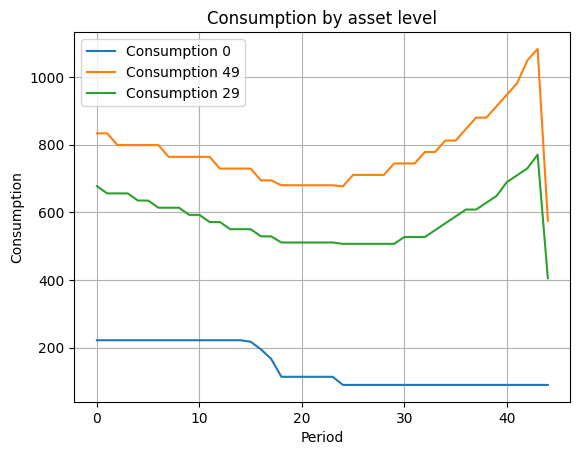

In [ ]:
plt.plot(c_unemp[0,:], label="Consumption 0")
plt.plot(c_unemp[49,:], label="Consumption 49")
plt.plot(c_unemp[29,:], label="Consumption 29")
#plt.plot(S[10,:], label="Search")
plt.xlabel("Period")
plt.ylabel("Consumption")
plt.title("Optimal Consumption by asset level")
plt.legend()
plt.grid(True)
plt.show()

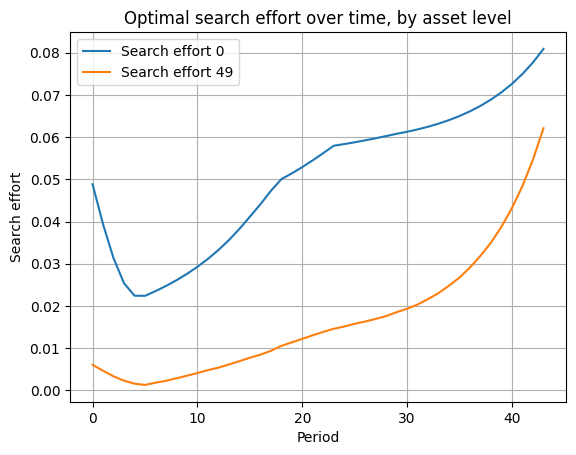

In [47]:
plt.plot(S[0,:-1], label="Search effort 0")
plt.plot(S[49,:-1], label="Search effort 49")
#plt.plot(S[10,:], label="Search")
plt.xlabel("Period")
plt.ylabel("Search effort")
plt.title("Optimal search effort over time, by asset level")
plt.legend()
plt.grid(True)
plt.show()

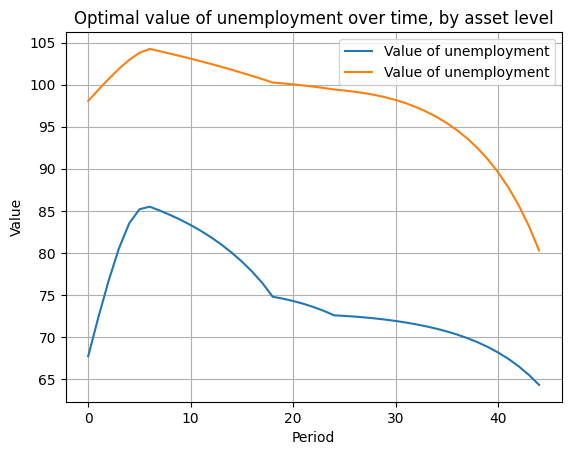

In [43]:
plt.plot(V_unemp[0,:], label="Value of unemployment")
plt.plot(V_unemp[49,:], label="Value of unemployment")
#plt.plot(S[10,:], label="Search")
plt.xlabel("Period")
plt.ylabel("Value")
plt.title("Optimal value of unemployment over time, by asset level")
plt.legend()
plt.grid(True)
plt.show()

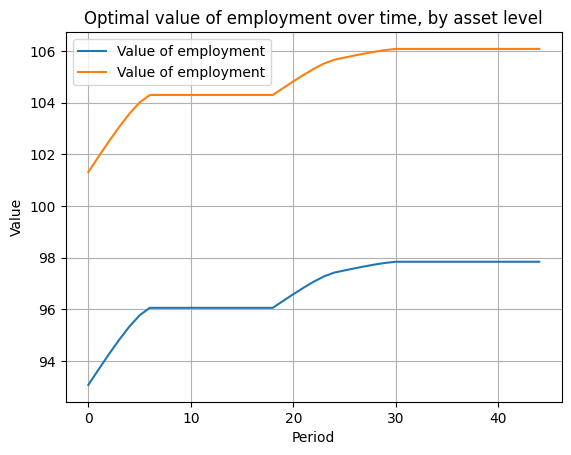

In [48]:
plt.plot(V_emp[0,:], label="Value of employment")
plt.plot(V_emp[49,:], label="Value of employment")
#plt.plot(S[10,:], label="Search")
plt.xlabel("Period")
plt.ylabel("Value")
plt.title("Optimal value of employment over time, by asset level")
plt.legend()
plt.grid(True)
plt.show()

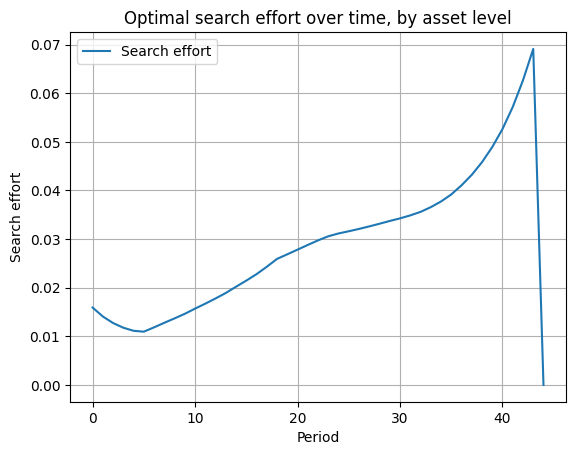

In [44]:
plt.plot(S[20,:], label="Search effort")

#plt.plot(S[10,:], label="Search")
plt.xlabel("Period")
plt.ylabel("Search effort")
plt.title("Optimal search effort over time, by asset level")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
# 1. Terminal conditions
print("Terminal unemployment value error:",
      np.max(np.abs(V_unemp[:, T] - Vss_uemp)))

print("Terminal search:",
      S[:, T].min(), S[:, T].max())

Terminal unemployment value error: 0.0
Terminal search: 0.0 0.0


In [49]:
print("finite-horizon c at T-1:")
print(c_unemp[:, T-1])

print("steady-state c at T:")
print(c_unemp[:, T])

print("difference:")
print(c_unemp[:, T-1] - c_unemp[:, T])

finite-horizon c at T-1:
[  90.          191.01010101  266.54192936  292.79438682  305.04508169
  339.45834181  364.38071995  395.86061962  397.80760626  415.72910311
  442.99369534  467.54660701  489.38783811  499.10039997  514.84034981
  538.64144804  561.08670599  582.17612365  601.90970104  606.80292862
  623.14690529  638.13504169  667.28560776  680.23998373  708.71262965
  719.6332452   729.19802047  737.40695546  763.84584096  770.02101552
  795.78198088  821.54294624  825.00644024  827.11409396  851.51921904
  875.92434411  900.32946919  899.0475222   922.77472714  946.50193207
  942.50830452  965.55758932  988.60687411 1011.6561589  1004.27293065
 1026.6442953  1049.01565996 1038.92075114 1060.61419565 1082.30764016
 1104.00108467 1125.69452918 1147.3879737  1132.54762389 1153.56314826
 1174.57867263 1195.594197   1216.60972137 1237.62524575 1218.03945495
 1238.37705918 1258.71466341 1279.05226764 1299.38987187 1319.7274761
 1340.06508033 1360.40268456 1334.7156125  1354.37529

In [51]:
print(V_unemp[:, T-1] - Vss_uemp)

[1.19587119 1.85008987 1.96561869 2.04358564 2.09097768 2.13340585
 2.17414655 2.21445604 2.2513098  2.28306271 2.31351429 2.34245205
 2.36975954 2.39465947 2.4168679  2.43790948 2.45857967 2.47897333
 2.49926912 2.51883603 2.53718723 2.5550069  2.5729174  2.59026311
 2.60728462 2.62400865 2.63922896 2.65418331 2.6689281  2.68319253
 2.69737338 2.71196141 2.7257116  2.73865894 2.75198399 2.7649543
 2.77750052 2.79047986 2.80362254 2.8148574  2.82664732 2.83831357
 2.84982272 2.86079524 2.87217934 2.88334107 2.8938698  2.90406936
 2.91471026 2.92517332 2.93545208 2.94556722 2.95540789 2.96539638
 2.97514342 2.98463925 2.99389266 3.00312415 3.01231092 3.02109362
 3.03038896 3.03933486 3.0479799  3.05657297 3.06505587 3.07348373
 3.08184666 3.09015209 3.09875535 3.10696557 3.11488182 3.12277971
 3.13060753 3.13829823 3.14591524 3.15339646 3.16097371 3.16847963
 3.17582584 3.18309837 3.19034665 3.19762347 3.20485801 3.21181079
 3.21880437 3.22577    3.23274629 3.2396922  3.24654795 3.25351

In [56]:
a_grid = np.linspace(abar[0], abar[1], n_a)

a_next_Tminus1 = (
    a_grid
    - c_unemp[:, T-1]
    + benefits[T-1]
) * (1 + R)

print(a_next_Tminus1)

[   0.            0.           25.73305539  101.23827537  190.88527557
  258.14808488  334.99668497  405.22218833  505.27593383  589.19542404
  663.67838791  740.90014914  820.86070775  913.07122229  999.19407498
 1077.17516779 1156.52565928 1237.24554945 1319.33483832 1416.41288048
 1501.92566606 1588.80785032 1661.38598061 1750.3222629  1823.58509254
 1914.57547285 2006.93525185 2100.66442953 2175.9813572  2271.76463291
 2347.76625991 2423.76788692 2522.28996    2622.18143177 2699.55245746
 2776.92348315 2854.29450885 2957.60947732 3035.66520236 3113.72092739
 3219.77469324 3298.51511762 3377.255542   3455.99596638 3565.47322893
 3644.89835265 3724.32347637 3836.5395363  3916.64935937 3996.75918243
 4076.86900549 4156.97882855 4237.08865162 4354.09760694 4434.89212935
 4515.68665175 4596.48117416 4677.27569656 4758.07021897 4879.87206969
 4961.35129144 5042.83051319 5124.30973493 5205.78895668 5287.26817843
 5368.74740018 5450.22662192 5578.19076673 5660.35468782 5742.51860891
 5824.

In [59]:
a_next_ss = (
    a_grid
    - css_uemp
    + welfare
) * (1 + R)

print(a_next_ss)

[   0.           64.73832283  148.45993492  234.44653244  321.49099044
  411.42351027  504.85415904  605.13180123  693.99345129  778.82153752
  872.47608298  960.72766592 1050.34864755 1141.33902786 1233.69880686
 1327.42798454 1422.52656091 1518.99453596 1616.8319097  1702.4193275
 1802.31079927 1888.58291641 1974.85503356 2077.48530269 2164.44211918
 2251.39893567 2356.76800217 2444.409518   2532.05103383 2640.1588977
 2728.48511287 2816.81132805 2927.65798929 3016.6689038  3105.67981832
 3194.69073283 3283.70164735 3372.71256186 3488.3521185  3578.04773236
 3667.74334621 3757.43896007 3847.13457393 3936.83018778 4026.52580164
 4147.64295302 4238.02326622 4328.40357942 4418.78389262 4509.16420582
 4599.54451902 4689.92483221 4780.30514541 4870.68545861 4961.06577181
 5089.71461596 5180.7796285  5271.84464104 5362.90965358 5453.97466612
 5545.03967867 5636.10469121 5727.16970375 5818.23471629 5909.29972883
 6000.36474137 6091.42975391 6182.49476646 6273.559779   6412.47911328
 6504.22

In [46]:
S, V_emp, V_unemp, c_emp, c_unemp, Vss_emp, Vss_uemp = SolveModel(delta, gamma, 0, k, lmbda, abar, n_a, n_c, T1, T2, T3, T, N, b1, b2, b3, welfare, w, R)

Asset grid:
2.220446049250313e-16 10000.0
A_next:
-9.185896487906575e-13 10781.75
Share above grid: 0.0034666666666666665
Share below grid: 0.006266666666666667
Asset grid:
2.220446049250313e-16 10000.0
A_next:
-9.185896487906575e-13 10781.75
Share above grid: 0.0034666666666666665
Share below grid: 0.006266666666666667
Asset grid:
2.220446049250313e-16 10000.0
A_next:
-9.185896487906575e-13 10781.75
Share above grid: 0.0034666666666666665
Share below grid: 0.006266666666666667
Asset grid:
2.220446049250313e-16 10000.0
A_next:
-9.185896487906575e-13 10781.75
Share above grid: 0.0034666666666666665
Share below grid: 0.006266666666666667
Asset grid:
2.220446049250313e-16 10000.0
A_next:
-9.185896487906575e-13 10781.75
Share above grid: 0.0034666666666666665
Share below grid: 0.006266666666666667
Asset grid:
2.220446049250313e-16 10000.0
A_next:
-9.185896487906575e-13 10781.75
Share above grid: 0.0034666666666666665
Share below grid: 0.006266666666666667
Asset grid:
2.220446049250313e-16 

ValueError: too many values to unpack (expected 7)

In [ ]:
def unemployment_BI(Vss, ref_path, delta, eta, lmbda , R, benefits, abar, T, N, n_a, n_c):
    
    abar[0] = np.maximum(np.finfo(float).eps, abar[0])              # vælger numerisk nul, så vi kan tage log. 
    a = np.linspace(abar[0], abar[1], n_a).reshape((n_a, 1))        # laver en n_a x 1 matrice med værdierne fra 0 til maks asset level. 

    c = np.empty((n_a, n_c))    # For hver state kan man vælge n_c forskellige niveauer af forbrug i perioden
    for i in range(n_a):        # vi kigger på alle rækkerne og tilføjer forbrugsmuligheder fra 0 og op til maks forbrug som er givet ved assets + løn.  
        c[i, :] = np.linspace(abar[0], (a[i]+w), n_c).reshape((1, n_c))     # Laver det om til en vektor med 1 række og n_c kolonner. 

    a1 = (a - c + w) * (1 + R)   # assets i næste periode

    V_unemp = np.zeros((, n_a))   # placeholder variable for getting the job in period in period T with asset value a. 
    c_unemp = np.zeros((T+1, n_a))   # associated optimal consumption, first period after job start, not really that relevant though...

    for j in np.arange(T+1):
        V0 = Vss   # steady state value from the value function iterations. 

        # step backward: n = N-1 (period closest to steady state) down to n = 0 (period job starts)
        for n in np.arange(N-1, -1, -1):
            interp = interpolate.interp1d(a[:, 0], V0, bounds_error=False, fill_value="extrapolate")    # here it always takes the latest V0 value, so a new one in every period. This is where the updated values get used. 
            V_next = interp(a1)     # V_next er jo altid den seneste værdi. Første del af loopet er så den 'interpolerede' værdi fra v_ss af givne asset levels mellem grids. 

            matV1 = np.log(c) + eta * lmbda * (np.log(c) - np.log(ref_path[-1, j+n])) + delta * V_next    # vi kigger kun på den nederste række i ref_path, fordi de aldrig får jobbet, men vi kigger stadig på den j'te periode og +n perioder frem. 
                                                            # og så fordi at c er defineret som alle forbrugsmuligheder med forskellige asset levels overholdet det budget begrænsningen. 
            i_max = np.argmax(matV1, axis=1)                # hvordan overholder vi budgetbegrænsningen i næste periode? 
            V0 = matV1[np.arange(n_a), i_max]               # her opdateres værdierne givet det optimale forbrugsval. Det bliver så genbrugt til næste periode. 
            c_current = c[np.arange(n_a), i_max]
    
        V_unemp[j, :] = V0
        c_unemp[j, :] = c_current
    
    return V_unemp, c_unemp

In [ ]:
test = np.array([1,2,3,4,5,6])
print(test[-1])

In [ ]:

# hvad skal vi ændre
# 1. lønnen, vi skal tilføje benefit path som løn
# 2. vi skal ændre initialle V0 til at være den steady state value for unemployed.
# 3. vi skal ændre ref_path til kun at være ref_path i den periode, hvor man aldrig får jobbet. Altså række T+1. 
